In [ ]:
import pandas as pd

# Carregando os dados da nova pasta organizada
dados = pd.read_csv('dados/emp_automovel.csv')
dados


,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [4]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y)

1.0

In [8]:
print(f'Acurácia: {modelo.score(x, y)}')

Acurácia: 1.0


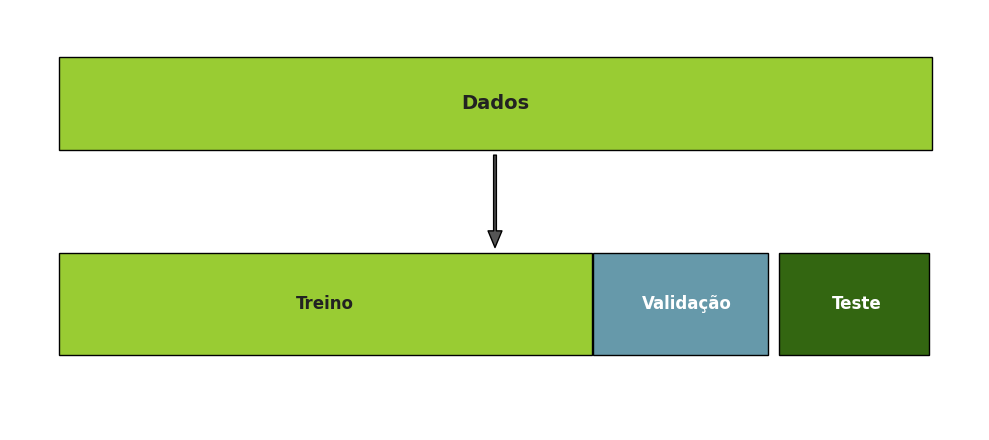

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 4.5))

# Estilo dos blocos (Cores)
cor_dados = '#99cc33'       
cor_treino = '#99cc33'      
cor_validacao = '#6699aa'   
cor_teste = '#336611'       

# 1. Bloco de "Dados" (Topo)
ax.add_patch(patches.Rectangle((0.5, 3.0), 9.0, 1.0, edgecolor='black', facecolor=cor_dados, lw=1))
ax.text(5.0, 3.5, 'Dados', fontsize=14, fontweight='bold', ha='center', va='center', color='#222222')

# Seta indicativa para baixo
ax.annotate('', xy=(5.0, 1.9), xytext=(5.0, 3.0),
            arrowprops=dict(facecolor='#555555', shrink=0.05, width=2, headwidth=10))

# 2. Blocos de Divisão (Base) - Com espaçamento reduzido
# Treino (Largura: 5.5)
ax.add_patch(patches.Rectangle((0.5, 0.8), 5.5, 1.1, edgecolor='black', facecolor=cor_treino, lw=1))
ax.text(3.25, 1.35, 'Treino', fontsize=12, fontweight='bold', ha='center', va='center', color='#222222')

# Validação (Começa logo após o Treino, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((6.01, 0.8), 1.8, 1.1, edgecolor='black', facecolor=cor_validacao, lw=1))
ax.text(6.98, 1.35, 'Validação', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Teste (Começa logo após a Validação, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((7.93, 0.8), 1.54, 1.1, edgecolor='black', facecolor=cor_teste, lw=1))
ax.text(8.73, 1.35, 'Teste', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Ajustes finais dos eixos
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [23]:
from sklearn.model_selection import train_test_split


In [24]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [25]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 1.0
Acurácia de Validação: 0.8480968556745928


In [27]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 0.9206445993031359
Acurácia de Validação: 0.9055831373573731


In [28]:
from sklearn.metrics import confusion_matrix


In [29]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10355   124]
 [  960    42]]


In [32]:
from sklearn.metrics import ConfusionMatrixDisplay


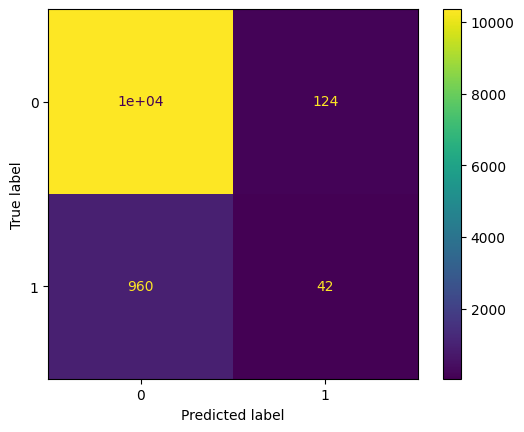

In [ ]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)
vizualizacao.plot()

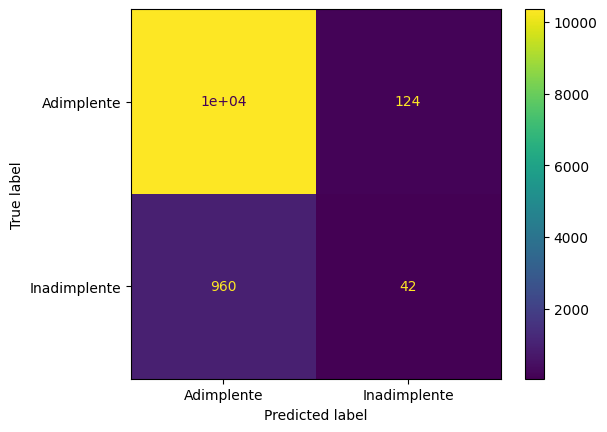

In [35]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
vizualizacao.plot()

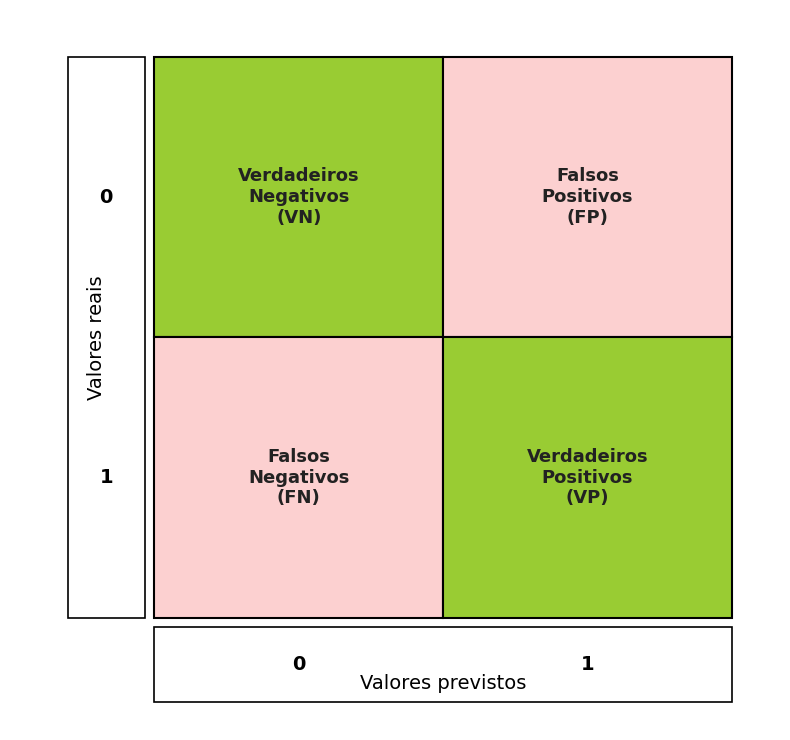

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(8, 7.5))

# Cores fiéis à imagem do curso
cor_acerto = '#99cc33'     # Verde claro (Verdadeiros)
cor_erro = '#fcd0d0'       # Rosa claro (Falsos)

# 1. Desenhar os Quadrantes Principais da Matriz
# Verdadeiros Negativos (VN)
ax.add_patch(patches.Rectangle((2, 4), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(3.5, 5.5, 'Verdadeiros\nNegativos\n(VN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Positivos (FP)
ax.add_patch(patches.Rectangle((5, 4), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(6.5, 5.5, 'Falsos\nPositivos\n(FP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Negativos (FN)
ax.add_patch(patches.Rectangle((2, 1), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(3.5, 2.5, 'Falsos\nNegativos\n(FN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Verdadeiros Positivos (VP)
ax.add_patch(patches.Rectangle((5, 1), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(6.5, 2.5, 'Verdadeiros\nPositivos\n(VP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# 2. Caixa Lateral Esquerda ("Valores reais") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((1.1, 1.0), 0.8, 6.0, edgecolor='black', facecolor='none', lw=1.2))
ax.text(1.5, 5.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.5, 2.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.4, 4.0, 'Valores reais', fontsize=14, rotation=90, ha='center', va='center')

# 3. Caixa Inferior ("Valores previstos") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((2.0, 0.1), 6.0, 0.8, edgecolor='black', facecolor='none', lw=1.2))
ax.text(3.5, 0.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(6.5, 0.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(5.0, 0.3, 'Valores previstos', fontsize=14, ha='center', va='center')

# Ajustes de exibição para esconder os eixos do gráfico padrão
ax.set_xlim(0.5, 8.5)
ax.set_ylim(-0.2, 7.5)
ax.axis('off')

plt.tight_layout()
plt.show()
